In [1]:
import torch, time
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data as data
import torch.optim as optim
import torch.nn.functional as F
import os, cv2, numpy as np, math, random
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from collections import Counter
from collections import defaultdict
import numpy as np, torch,shutil
from torch.utils.data import Subset
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(2025)

### 데이터 불러오기

In [2]:
def extract_largest_square(img):
    """
    가장 큰 contour의 bounding square만 남기고 나머지는 검정색으로 처리하는 함수.
    img: 2D numpy array (grayscale)
    """
    # 1. Edge 검출 (Canny)
    edges = cv2.Canny(img, 50,150)

    # 2. Contour 추출
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 3. 가장 넓은 사각형 찾기
    max_area = 0
    best_rect = None
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        if area > max_area:
            max_area = area
            best_rect = (x, y, w, h)

    # 4. 새 마스크 생성하여 사각형 내부만 살리기
    mask = np.zeros_like(img)
    if best_rect:
        x, y, w, h = best_rect
        mask[y:y+h, x:x+w] = img[y:y+h, x:x+w]

    return mask

In [3]:
def extract_largest_crop_and_resize(img, output_size=32):
    """
    가장 큰 contour를 포함하는 사각형 영역만 crop한 후, 지정 크기로 resize하여 반환
    img: 2D numpy array (grayscale)
    output_size: 최종 출력 크기 (정사각형, 예: 32)
    """
    # 1. Edge 검출 (Canny)
    edges = cv2.Canny(img, 50, 150)

    # 2. Contour 추출
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 3. 가장 큰 contour의 bounding box 찾기
    max_area = 0
    best_rect = None
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        if area > max_area:
            max_area = area
            best_rect = (x, y, w, h)

    if best_rect:
        x, y, w, h = best_rect
        cropped = img[y:y+h, x:x+w]
        resized = cv2.resize(cropped, (output_size, output_size), interpolation=cv2.INTER_AREA)
        return resized
    else:
        # fallback: resize 원본
        return cv2.resize(img, (output_size, output_size), interpolation=cv2.INTER_AREA)


In [4]:
class CustomImageDataset(Dataset):
    def __init__(self, image_folder):
        """
        image_folder: 이미지가 저장된 폴더 (상대 또는 절대 경로)
        파일명 예시: Train_aug_0005_3.png → 라벨 = 3
        """
        self.image_paths = []
        self.labels = []

        image_path = os.path.join(os.getcwd(), image_folder)

        for filename in os.listdir(image_path):
            if filename.endswith('.png'):
                full_path = os.path.join(image_path, filename)

                # 라벨 추출 (뒤에서 _숫자.png 형태)
                label = int(filename.split('_')[-1].split('.')[0])

                self.image_paths.append(full_path)
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 이미지 로드 (흑백)
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)

        # img = extract_largest_square(img) # 가장 큰 사각형만 남기기
        img = extract_largest_crop_and_resize(img, output_size=32) # 가장 큰 contour를 포함하는 사각형 영역만 crop 후 resize

        # 크기 통일
        if img.shape != (32, 32):
            img = cv2.resize(img, (32, 32))

        # 정규화 + 채널 차원 추가
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)  # (1, 32, 32)

        # 텐서로 변환
        img_tensor = torch.tensor(img, dtype=torch.float32)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)

        return img_tensor, label_tensor


In [5]:
dataset = CustomImageDataset('data/train')
test_dataset = CustomImageDataset('data/test')
print(f"Train dataset size: {len(dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 769
Test dataset size: 250


In [6]:
print(Counter(dataset.labels))

Counter({4: 128, 5: 119, 0: 108, 2: 95, 1: 90, 3: 88, 9: 51, 7: 37, 6: 32, 8: 21})


### 데이터 증강 

In [7]:
class BalancedDataset(Dataset):
    def __init__(self, base_dataset, target_count=90):
        self.base_dataset = base_dataset
        self.target_count = target_count

        labels = base_dataset.labels
        class_counts = Counter(labels)

        self.class_indices = {cls: [] for cls in set(labels)}
        for idx, (_, label) in enumerate(base_dataset):
            label = int(label)
            self.class_indices[label].append(idx)

        self.indices = []
        self.labels = []  

        for cls, idx_list in self.class_indices.items():
            if len(idx_list) >= self.target_count:
                selected = random.sample(idx_list, self.target_count)
            else:
                selected = idx_list.copy()
                while len(selected) < self.target_count:
                    selected.append(random.choice(idx_list))
            self.indices.extend(selected)
            self.labels.extend([cls] * self.target_count)  # ✅ 클래스 번호를 같이 저장

        random.seed(2025)
        combined = list(zip(self.indices, self.labels))
        random.shuffle(combined)
        self.indices, self.labels = zip(*combined)  # 다시 분리해서 저장
        self.indices = list(self.indices)
        self.labels = list(self.labels)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = self.indices[idx]
        img, label = self.base_dataset[base_idx]
        return img, label

In [8]:
class AugmentedDataset(Dataset):
    def __init__(self, base_dataset, multiply_factor=5, transform=None):
        self.base_dataset = base_dataset
        self.multiply_factor = multiply_factor
        self.transform = transform

        self.indices = []
        self.labels = []
        self.images = []

        for idx in range(len(base_dataset)):
            img, label = base_dataset[idx]
            label = int(label)  # ✅ tensor -> int 변환

            for _ in range(multiply_factor):
                self.indices.append(idx)
                self.labels.append(label)
                self.images.append(img)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = self.indices[idx]
        img = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


In [9]:

# ✅ 사용자 정의 GaussianNoise transform
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.03):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

    def __repr__(self):
        return f'{self.__class__.__name__}(mean={self.mean}, std={self.std})'
# ✅ 전체 증강 파이프라인
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    transforms.RandomRotation(10),  # 추가: 더 다양한 회전
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1)
    ], p=0.5),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.3),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),  # scale 강화
    transforms.Normalize(mean=[0.5], std=[0.5]),
])




In [10]:
aug_dataset = BalancedDataset(dataset, target_count=90)
aug_dataset = AugmentedDataset(aug_dataset, multiply_factor=5, transform=train_transform)
aug_labels = aug_dataset.labels
aug_label_counts = Counter(aug_labels)
print(aug_label_counts)

Counter({5: 450, 7: 450, 9: 450, 8: 450, 2: 450, 1: 450, 0: 450, 3: 450, 4: 450, 6: 450})


In [11]:
def stratified_split(dataset, train_ratio=0.8, seed=2025):
    """
    PyTorch Dataset을 라벨 비율에 따라 stratified하게 train/val로 나눔
    중복 없이 분할됨
    """
    np.random.seed(seed)
    label_to_indices = defaultdict(list)

    # 라벨별 인덱스 수집
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        label = int(label)
        label_to_indices[label].append(idx)

    train_indices, val_indices = [], []

    for label, indices in label_to_indices.items():
        indices = np.array(indices)
        np.random.shuffle(indices)
        n_train = int(len(indices) * train_ratio)
        train_indices.extend(indices[:n_train].tolist())
        val_indices.extend(indices[n_train:].tolist())

    # 중복 없음 확인
    assert len(set(train_indices).intersection(set(val_indices))) == 0, "Train/Val overlap detected!"

    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)

    return train_subset, val_subset


In [12]:
### Train / Validation Split
train_dataset, val_dataset = stratified_split(aug_dataset, train_ratio=0.8, seed=2025)
train_labels = [aug_dataset.labels[i] for i in train_dataset.indices]
val_labels = [aug_dataset.labels[i] for i in val_dataset.indices]

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Train labels: {Counter(train_labels)}")
print(f"Validation labels: {Counter(val_labels)}")

Train dataset size: 3600
Validation dataset size: 900
Train labels: Counter({5: 360, 7: 360, 9: 360, 8: 360, 2: 360, 1: 360, 0: 360, 3: 360, 4: 360, 6: 360})
Validation labels: Counter({5: 90, 7: 90, 9: 90, 8: 90, 2: 90, 1: 90, 0: 90, 3: 90, 4: 90, 6: 90})


### Train 관련 지정 

In [13]:
def train(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    scheduler=None,
    device='cuda',
    num_epochs=100,
    early_stop_patience=10,
    log_dir="./runs",
):
    model = model.to(device)
    if os.path.exists(log_dir):
        shutil.rmtree(log_dir)
        print(f"✅ Removed existing log directory: {log_dir}")
    os.makedirs(log_dir, exist_ok=True)
    writer = SummaryWriter(log_dir=log_dir)

    best_val_acc = 0.0
    patience = 0
    best_model_state = None

    try:
        for epoch in range(1, num_epochs + 1):
            model.train()
            train_loss = 0.0
            correct = 0
            total = 0

            train_bar = tqdm(train_loader, desc=f"[Epoch {epoch}/{num_epochs}] Training", leave=False, position=0)
            for batch_idx, (imgs, labels) in enumerate(train_bar):
                imgs, labels = imgs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(imgs)
                loss = loss_fn(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            train_acc = correct / total
            train_loss /= total

            # 🔍 Validation
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    outputs = model(imgs)
                    loss = loss_fn(outputs, labels)

                    val_loss += loss.item() * imgs.size(0)
                    _, preds = torch.max(outputs, 1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            val_acc = val_correct / val_total
            val_loss /= val_total

            # 🔼 Logging
            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Loss/val", val_loss, epoch)
            writer.add_scalar("Acc/train", train_acc, epoch)
            writer.add_scalar("Acc/val", val_acc, epoch)

            # print(f"[Epoch {epoch}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

            # 🔁 Scheduler step
            if scheduler:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(val_loss)
                else:
                    scheduler.step()

            # 🛑 Early Stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict()
                patience = 0
            else:
                patience += 1
                if patience >= early_stop_patience:
                    print(f"🛑 Early stopping at epoch {epoch}")
                    break

    except Exception as e:
        print(f"⚠️ Training stopped due to error: {e}")

    # ✅ Save best model
    if best_model_state:
        time.sleep(5)
        print("Saving best model...")
        model.load_state_dict(best_model_state)
        torch.save(model.state_dict(), os.path.join(log_dir, "best_model.pth"))
        print(f"✅ Best model saved with Val Acc: {best_val_acc:.4f}")

    writer.close()
    return model


In [14]:
import torch
from torch.utils.data import  DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import os

def fine_tuning(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    scheduler=None,
    device='cuda',
    num_epochs=100,
    log_dir="./runs"
):
    model = model.to(device)

    # 2. train + val 데이터를 하나로 합침
    full_dataset = ConcatDataset([train_loader.dataset, val_loader.dataset])
    full_loader = DataLoader(full_dataset, batch_size=train_loader.batch_size, shuffle=True, num_workers=0)

    # 3. 로그 기록 설정
    finetune_log_dir = log_dir + "_finetune"
    if os.path.exists(finetune_log_dir):
        shutil.rmtree(finetune_log_dir)
        print(f"✅ Removed existing log directory: {finetune_log_dir}")
    os.makedirs(finetune_log_dir, exist_ok=True)
    writer = SummaryWriter(log_dir=finetune_log_dir)

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for imgs, labels in tqdm(full_loader, desc=f"[Fine-tune Epoch {epoch}/{num_epochs}]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        writer.add_scalar("Loss/train", epoch_loss, epoch)
        writer.add_scalar("Acc/train", epoch_acc, epoch)

        if scheduler:
            scheduler.step()

    # 4. 모델 저장
    torch.save(model.state_dict(), os.path.join(finetune_log_dir, "finetuned_model.pth"))
    print(f"✅ Fine-tuned model saved to {finetune_log_dir}/finetuned_model.pth")

    writer.close()

In [15]:
class FocalLabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1, gamma=2.0):
        super().__init__()
        self.smoothing = smoothing
        self.gamma = gamma

    def forward(self, logits, target):
        num_classes = logits.size(1)
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()

        # Label smoothing
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (num_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

        focal_weight = ((1 - probs).pow(self.gamma)).detach()
        loss = (-true_dist * log_probs * focal_weight).sum(dim=1).mean()
        return loss


### 모델링

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)

    def forward(self, x):
        b, c, _, _ = x.shape
        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = F.silu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y

class Net(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(2)  # (32, 16, 16)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.MaxPool2d(2),  # (64, 8, 8)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.MaxPool2d(2),  # (128, 4, 4)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.SiLU(),
            SEBlock(256),                     # ✅ 채널 attention
            nn.AdaptiveAvgPool2d(1),          # (256, 1, 1)
        )

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(256, num_classes)  # ▶ Linear 대신 CosineClassifier도 가능

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.classifier(x)


### Training 시작 

In [17]:
# Hyperparameters
BATCH_SIZE = 256
NUM_CLASSES = 10
NUM_EPOCHS = 500
LEARNING_RATE = 1e-3*BATCH_SIZE/256

In [18]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cuda


In [19]:
#model 
set_seed(2025)
model = Net(num_classes=NUM_CLASSES).to(DEVICE)
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
schuduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
# Loss function
loss_fn = nn.CrossEntropyLoss() # 다중 클래스 분류에 적합한 손실 함수
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
# Train the model
trained_model = train(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    scheduler=schuduler,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    num_epochs=NUM_EPOCHS,
    early_stop_patience=20,
    log_dir="./runs",
)

✅ Removed existing log directory: ./runs


🛑 Early stopping at epoch 79
Saving best model...
✅ Best model saved with Val Acc: 0.9589


### Final Training

In [20]:
model = Net(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load("./runs/best_model.pth", map_location=DEVICE))
set_seed(2025)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

fine_tuning(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    scheduler=None,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    num_epochs=5,
    log_dir="./runs",
)


✅ Removed existing log directory: ./runs_finetune


✅ Fine-tuned model saved to ./runs_finetune/finetuned_model.pth


### Inference

In [21]:
model = Net(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load("./runs_finetune/finetuned_model.pth", map_location=DEVICE))
model.eval();

In [22]:
import torch
from torchvision import transforms

def tta_predict(model, image_tensor, device='cuda', n_aug=5):
    model.eval()
    image_tensor = image_tensor.to(device)
    preds = []

    tta_transforms = [
        transforms.Compose([]),
        transforms.Compose([transforms.RandomRotation(10)]),
        transforms.Compose([transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))]),
        transforms.Compose([transforms.RandomErasing(p=0.7, scale=(0.02, 0.2))]),
    ]

    normalize = transforms.Normalize(mean=[0.5], std=[0.5])

    with torch.no_grad():
        for i in range(n_aug):
            img = image_tensor.clone().squeeze(0).cpu()  # (1, 1, 32, 32) → (1, 32, 32)
            transform = tta_transforms[i % len(tta_transforms)]
            img = transform(img)  # Tensor 기반 transform
            img = normalize(img).unsqueeze(0).to(device)

            output = model(img)
            preds.append(torch.softmax(output, dim=1))

    return torch.stack(preds).mean(dim=0)


In [23]:
import pandas as pd, json
answer = pd.read_csv('data/label.txt', delimiter=',')
encode = json.load(open('data/label_encode.json', 'r'))
print(len(answer))
# 라벨 인코딩을 위한 딕셔너리 로드
def change_labels(dataloder,answer,encoder:dict):
    paths = dataloder.dataset.image_paths # 이미지 경로
    labels = []
    for path in paths:
        name = path.split('/')[-1]
        name = name.split('\\')[-1].replace('.png','')
        name = name.split('_')[1]
        name = int(name)
        label_eng = answer[answer.ID==name].values[0][1].strip() # 라벨 영어로 변환
        label = encoder[label_eng]
        label = int(label)
        labels.append(label)
    print(f"Test dataset size: {len(dataloder.dataset)}")
    print(f"Test labels: {Counter(labels)}")
    dataloder.dataset.labels = labels # 라벨 업데이트
change_labels(test_loader, answer, encode)

250
Test dataset size: 250
Test labels: Counter({2: 25, 1: 25, 3: 25, 0: 25, 6: 25, 7: 25, 8: 25, 9: 25, 5: 25, 4: 25})


In [24]:
def inference(model, test_loader, device='cuda'):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for imgs, _ in tqdm(test_loader, desc="Inference", leave=False):
            imgs = imgs.to(device)
            # preds = tta_predict(model, imgs, device=device, n_aug=5)
            preds = model(imgs)
            preds = torch.argmax(preds, dim=1).cpu().numpy() # 예측된 클래스 인덱스
            all_preds.extend(preds)

    return all_preds, test_loader.dataset.labels

inference_labels, test_labels = inference(trained_model, test_loader, device=DEVICE)

### 분석 

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json


# 리포트 작성 
report = classification_report(test_labels, inference_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df


c:\Users\na062\Desktop\dacon\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\na062\Desktop\dacon\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\na062\Desktop\dacon\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
0,0.396825,1.000,0.568182,25.000
1,0.000000,0.000,0.000000,25.000
2,1.000000,0.160,0.275862,25.000
3,1.000000,0.080,0.148148,25.000
4,0.000000,0.000,0.000000,25.000
5,0.150943,0.960,0.260870,25.000
6,1.000000,0.040,0.076923,25.000
7,0.684211,0.520,0.590909,25.000
8,0.000000,0.000,0.000000,25.000
9,1.000000,0.080,0.148148,25.000


0.284


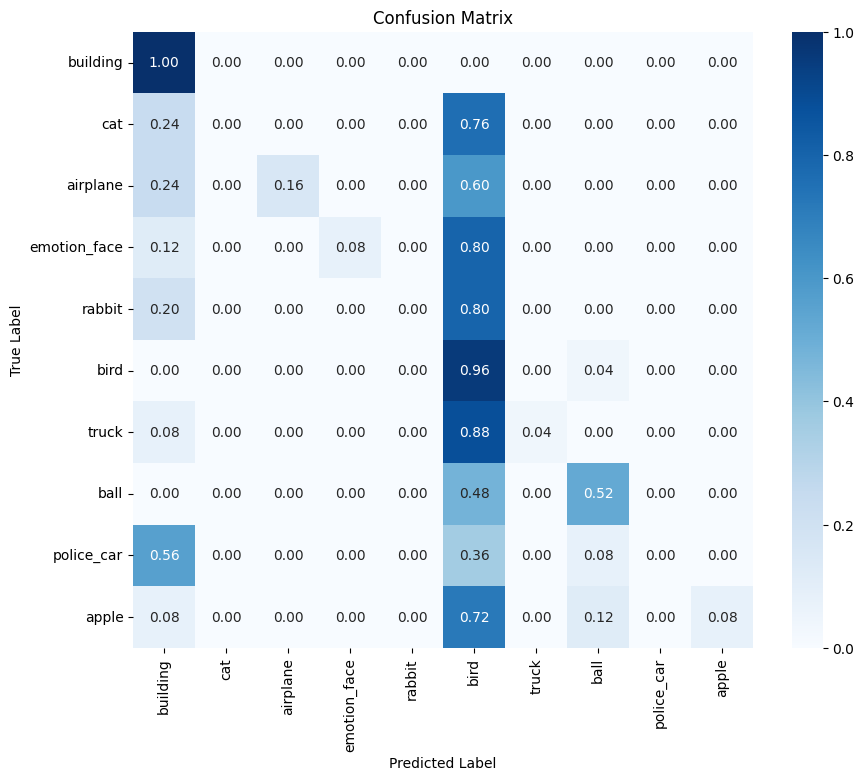

In [26]:
print(accuracy_score(test_labels, inference_labels)) # 정확도
cons = confusion_matrix(test_labels, inference_labels)
cons = cons.astype('float') / cons.sum(axis=1)[:, np.newaxis] # 정규화
plt.figure(figsize=(10, 8))
sns.heatmap(cons, annot=True, fmt='.2f', cmap='Blues', xticklabels=encode.keys(), yticklabels=encode.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 제출

In [27]:
import pandas as pd
df = pd.read_csv('data/sample_submission.csv')
df['label'] = inference_labels
decode = {v: k for k, v in encode.items()}
df['label'] = df['label'].map(decode) # 라벨 디코딩
df.to_csv('submission.csv', index=False)

### 